#Imports

In [1]:
import os
import json
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

#Load Dataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATASET_DIR = "/content/drive/MyDrive/Face recognition dataset/105_classes_pins_dataset"

OUTPUT_DIR = "/content/drive/MyDrive/Face recognition dataset/prepared_data"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
persons = sorted([p for p in os.listdir(DATASET_DIR)
    if os.path.isdir(
        os.path.join(DATASET_DIR,p)
    )
])

print("Persons :",len(persons))

Persons : 105


#Data Visualization

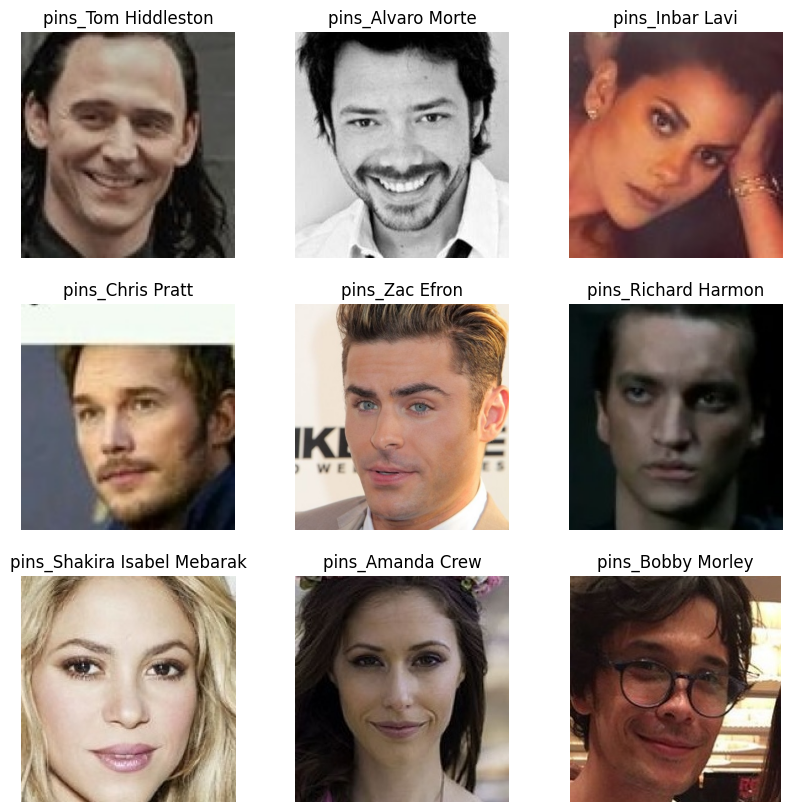

In [7]:
plt.figure(figsize=(10,10))

for i in range(9):

    person = random.choice(persons)

    img = random.choice(dataset[person])

    plt.subplot(3,3,i+1)

    plt.imshow(Image.open(img))

    plt.title(person)

    plt.axis("off")

plt.show()

#Data Preparation

In [5]:
dataset = {}

for person in persons:

    folder = os.path.join(DATASET_DIR,person)

    images = sorted(

    [
        os.path.join(folder,img)
        for img in os.listdir(folder)
        if img.lower().endswith(
            (".jpg",".jpeg",".png")
        )
    ]
)

    dataset[person] = images

In [6]:
counts = [len(v) for v in dataset.values()]

print("Minimum :",min(counts))

print("Maximum :",max(counts))

print("Average :",np.mean(counts))

Minimum : 86
Maximum : 237
Average : 166.9904761904762


In [8]:
def generate_positive_pairs(images, max_pairs=150):

    all_pairs = list(itertools.combinations(images, 2))

    random.shuffle(all_pairs)

    return all_pairs[:max_pairs]

In [9]:
def generate_negative_pairs(dataset,person,max_pairs=150):

    pairs = set()

    own_images = dataset[person]

    other_people = [

        p for p in dataset

        if p != person

    ]

    while len(pairs) < max_pairs:

        img1 = random.choice(own_images)

        other = random.choice(other_people)

        img2 = random.choice(dataset[other])

        pairs.add((img1,img2))

    return list(pairs)

In [10]:
pairs=[]

for person in persons:

    positive = generate_positive_pairs(dataset[person], max_pairs=150)

    for p1,p2 in positive:

        pairs.append({"anchor":p1, "twin":p2, "label":1})

    negative = generate_negative_pairs(dataset, person, max_pairs=150)

    for p1,p2 in negative:

        pairs.append({ "anchor":p1, "twin":p2, "label":0})

print(len(pairs))

31500


In [11]:
pairs = pd.DataFrame(pairs)

pairs = pairs.sample(frac=1, random_state=SEED).reset_index(drop=True)

In [12]:
train_df,temp_df = train_test_split(
    pairs,
    test_size=0.20,
    stratify=pairs["label"],
    random_state=SEED
)

In [13]:
val_df,test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED

)

In [14]:
print("Train :",len(train_df))

print("Validation :",len(val_df))

print("Test :",len(test_df))

Train : 25200
Validation : 3150
Test : 3150


In [15]:
print(train_df["label"].value_counts())

print(val_df["label"].value_counts())

print(test_df["label"].value_counts())

label
1    12600
0    12600
Name: count, dtype: int64
label
0    1575
1    1575
Name: count, dtype: int64
label
0    1575
1    1575
Name: count, dtype: int64


In [16]:
train_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "train_pairs.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "val_pairs.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_pairs.csv"
    ),
    index=False
)

In [17]:
config = {

    "persons":len(persons),

    "train_pairs":len(train_df),

    "validation_pairs":len(val_df),

    "test_pairs":len(test_df),

    "positive_pairs_per_person":300,

    "negative_pairs_per_person":300,

    "image_size":100

}

with open(
    os.path.join(
        OUTPUT_DIR,
        "config.json"
    ),
    "w"

) as f:

    json.dump(config,f,indent=4)

#Train

In [19]:
IMG_SIZE = 100

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

DATA_DIR = "/content/drive/MyDrive/Face recognition dataset/prepared_data"

In [20]:
train_df = pd.read_csv(os.path.join(DATA_DIR,"train_pairs.csv"))

val_df = pd.read_csv(os.path.join(DATA_DIR,"val_pairs.csv"))

test_df = pd.read_csv(os.path.join(DATA_DIR,"test_pairs.csv"))

print(train_df.head())

                                              anchor  \
0  /content/drive/MyDrive/Face recognition datase...   
1  /content/drive/MyDrive/Face recognition datase...   
2  /content/drive/MyDrive/Face recognition datase...   
3  /content/drive/MyDrive/Face recognition datase...   
4  /content/drive/MyDrive/Face recognition datase...   

                                                twin  label  
0  /content/drive/MyDrive/Face recognition datase...      1  
1  /content/drive/MyDrive/Face recognition datase...      0  
2  /content/drive/MyDrive/Face recognition datase...      1  
3  /content/drive/MyDrive/Face recognition datase...      1  
4  /content/drive/MyDrive/Face recognition datase...      0  


In [21]:
train_anchor = train_df["anchor"].values
train_twin = train_df["twin"].values
train_label = train_df["label"].values.astype("float32")

val_anchor = val_df["anchor"].values
val_twin = val_df["twin"].values
val_label = val_df["label"].values.astype("float32")

test_anchor = test_df["anchor"].values
test_twin = test_df["twin"].values
test_label = test_df["label"].values.astype("float32")

In [22]:
augment = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.08),

    tf.keras.layers.RandomZoom(0.10),

    tf.keras.layers.RandomContrast(0.15)

])

In [23]:
def read_image(path):

    image = tf.io.read_file(path)

    image = tf.io.decode_jpeg(image, channels=3)

    image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))

    image = tf.cast(image,tf.float32)/255.0

    return image

In [24]:
def preprocess_train(anchor,twin,label):

    anchor = read_image(anchor)

    twin = read_image(twin)

    anchor = augment(anchor)

    twin = augment(twin)

    return (anchor,twin),label

In [25]:
def preprocess_test(anchor,twin,label):

    anchor = read_image(anchor)

    twin = read_image(twin)

    return (anchor,twin),label

In [26]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_anchor,
        train_twin,
        train_label
    )
)

In [27]:
train_dataset = (
    train_dataset
    .shuffle(
        10000,
       seed=SEED
    )
    .map(
        preprocess_train,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [28]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_anchor,
        val_twin,
        val_label
    )
)

In [29]:
val_dataset = (
    val_dataset
    .map(
        preprocess_test,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [30]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_anchor,
        test_twin,
        test_label
    )
)

In [31]:
test_dataset = (

    test_dataset
    .map(
        preprocess_test,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [32]:
for (anchor, twin), label in train_dataset.take(1):

    print("Anchor:", anchor.shape)
    print("Twin:", twin.shape)
    print("Label:", label.shape)

Anchor: (32, 100, 100, 3)
Twin: (32, 100, 100, 3)
Label: (32,)


In [34]:
class L2Normalization(tf.keras.layers.Layer):

    def call(self, x):
        return tf.math.l2_normalize(x, axis=1)

In [35]:
IMG_SIZE = 100
EMBEDDING_SIZE = 256

In [36]:
def build_embedding():

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(256, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(512, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation="relu")(x)
    x = Dropout(0.3)(x)

    x = Dense(EMBEDDING_SIZE)(x)

    outputs = L2Normalization()(x)

    return Model(inputs, outputs, name="EmbeddingModel")

In [37]:
embedding_model = build_embedding()

embedding_model.summary()

Model: "EmbeddingModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 256)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,948,800 (7.43 MB)

 Trainable params: 1,946,880 (7.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [38]:
embedding_model.save("embedding_model.keras")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

In [40]:
class L2Normalization(tf.keras.layers.Layer):

    def call(self, x):

        return tf.math.l2_normalize(
            x,
            axis=1
        )

In [41]:
def euclidean_distance(inputs):

    x,y = inputs

    return tf.sqrt(

        tf.reduce_sum(

            tf.square(x-y),

            axis=1,

            keepdims=True

        )+1e-8

    )

In [42]:
anchor = Input(
    shape=(100,100,3)
)

twin = Input(
    shape=(100,100,3)
)

anchor_embedding = embedding_model(anchor)

twin_embedding = embedding_model(twin)

distance = Lambda(

    euclidean_distance,
    name="distance"
)(
    [anchor_embedding, twin_embedding]
)

siamese_model = Model(

    inputs=[
        anchor,
        twin
    ],
    outputs=distance
)

In [43]:
def contrastive_loss(
    y_true,
    y_pred,
    margin=1.0
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    positive = y_true * tf.square(y_pred)
    negative = (
        1-y_true
    ) * tf.square(
        tf.maximum(
            margin-y_pred, 0
        )
    )

    return tf.reduce_mean(

        positive+negative

    )

In [44]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

siamese_model.compile(
    optimizer=optimizer,
    loss=contrastive_loss
)

In [45]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_embedding.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )

]

In [46]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

In [47]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_embedding.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [48]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [49]:
history = siamese_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 0.2917
Epoch 1: val_loss improved from None to 0.26925, saving model to best_embedding.keras

Epoch 1: finished saving model to best_embedding.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 6908s 9s/step - loss: 0.2590 - val_loss: 0.2692 - learning_rate: 1.0000e-04
Epoch 2/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 0.2472
Epoch 2: val_loss improved from 0.26925 to 0.26005, saving model to best_embedding.keras

Epoch 2: finished saving model to best_embedding.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 361s 458ms/step - loss: 0.2457 - val_loss: 0.2600 - learning_rate: 1.0000e-04
Epoch 3/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - loss: 0.2429
Epoch 3: val_loss improved from 0.26005 to 0.24878, saving model to best_embedding.keras

Epoch 3: finished saving model to best_embedding.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 364s 462ms/step - loss: 0.2409 - val_loss: 0.2488 - learning_rate: 1.0000e-04
Epoch 4/30
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 43

In [50]:
embedding_model.save(
    "final_embedding_model.keras"
)

#Evaluate

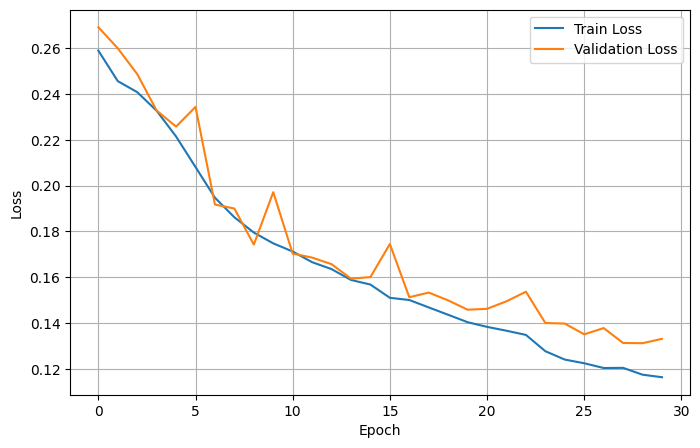

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
distances = []
labels = []

for (anchor, twin), y in test_dataset:

    d = siamese_model.predict([anchor, twin], verbose=0)

    distances.extend(d.flatten())

    labels.extend(y.numpy())

distances = np.array(distances)
labels = np.array(labels)

print("Total samples:", len(distances))

Total samples: 3150


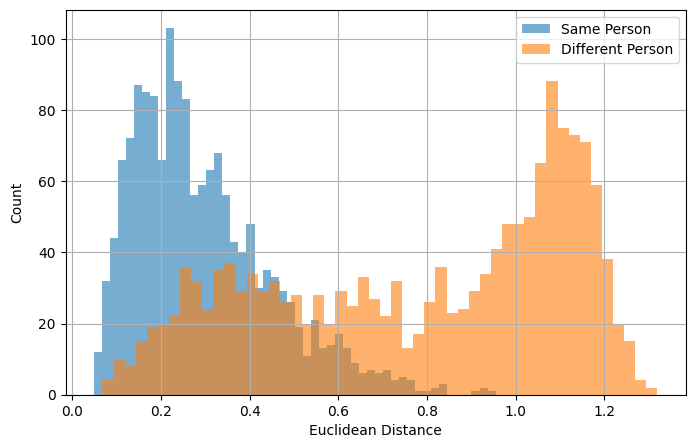

In [54]:
positive = distances[labels == 1]
negative = distances[labels == 0]

plt.figure(figsize=(8,5))

plt.hist(
    positive,
    bins=50,
    alpha=0.6,
    label="Same Person"
)

plt.hist(
    negative,
    bins=50,
    alpha=0.6,
    label="Different Person"
)

plt.xlabel("Euclidean Distance")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
best_threshold = 0
best_accuracy = 0

thresholds = np.arange(0,2,0.01)

for th in thresholds:

    predictions = (distances < th).astype(int)

    acc = np.mean(predictions == labels)

    if acc > best_accuracy:

        best_accuracy = acc
        best_threshold = th

print("Best Threshold :", best_threshold)
print("Best Accuracy  :", best_accuracy)

Best Threshold : 0.51
Best Accuracy  : 0.8133333333333334


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

pred = (distances < best_threshold).astype(int)

print("Accuracy :", accuracy_score(labels, pred))
print("Precision:", precision_score(labels, pred))
print("Recall   :", recall_score(labels, pred))
print("F1 Score :", f1_score(labels, pred))

Accuracy : 0.8133333333333334
Precision: 0.766612641815235
Recall   : 0.900952380952381
F1 Score : 0.8283712784588442


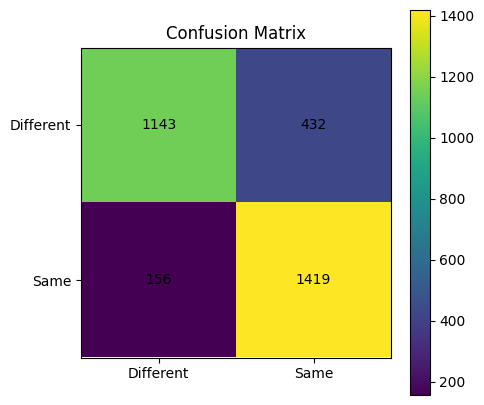

In [57]:
cm = confusion_matrix(labels, pred)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Different","Same"])
plt.yticks([0,1],["Different","Same"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center")

plt.show()

In [58]:
print(f"SIMILARITY_THRESHOLD = {best_threshold:.3f}")

SIMILARITY_THRESHOLD = 0.510


#Convert Embedding Model to TFLite

In [59]:
import tensorflow as tf
from tensorflow.keras.models import load_model

In [60]:
class L2Normalization(tf.keras.layers.Layer):

    def call(self, x):
        return tf.math.l2_normalize(x, axis=1)

In [61]:
embedding_model = load_model(
    "final_embedding_model.keras",
    custom_objects={
        "L2Normalization": L2Normalization
    }
)

embedding_model.summary()

Model: "EmbeddingModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 256)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,948,800 (7.43 MB)

 Trainable params: 1,946,880 (7.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [62]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    embedding_model
)

tflite_model = converter.convert()

Saved artifact at '/tmp/tmp1q2fd97g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 256), dtype=tf.float32, name=None)
Captures:
  137906145723600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145724752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145728400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145729552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145728784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145723792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145724560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145729168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906145723984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906635351696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13790614572

In [63]:
MODEL_NAME = "face_recognition_model.tflite"

with open(MODEL_NAME, "wb") as f:
    f.write(tflite_model)

print("Model saved successfully.")

Model saved successfully.


In [64]:
interpreter = tf.lite.Interpreter(
    model_path=MODEL_NAME
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input_layer_1:0', 'index': 0, 'shape': array([  1, 100, 100,   3], dtype=int32), 'shape_signature': array([ -1, 100, 100,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 40, 'shape': array([  1, 256], dtype=int32), 'shape_signature': array([ -1, 256], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [65]:
import numpy as np

dummy = np.random.rand(
    1,
    100,
    100,
    3
).astype(np.float32)

interpreter.set_tensor(
    input_details[0]["index"],
    dummy
)

interpreter.invoke()

embedding = interpreter.get_tensor(
    output_details[0]["index"]
)

print("Embedding Shape :", embedding.shape)

print("L2 Norm :", np.linalg.norm(embedding))

Embedding Shape : (1, 256)
L2 Norm : 1.0
